In [1]:
# Check the actual dataset structure first
import os
for root, dirs, files in os.walk('/kaggle/input/datasets/ashery/chexpert'):
    print(root, '->', dirs[:5], files[:3])
    if root.count(os.sep) - '/kaggle/input/datasets/ashery/chexpert'.count(os.sep) > 2:
        break

/kaggle/input/datasets/ashery/chexpert -> ['valid', 'train'] ['valid.csv', 'train.csv']
/kaggle/input/datasets/ashery/chexpert/valid -> ['patient64611', 'patient64545', 'patient64711', 'patient64612', 'patient64684'] []
/kaggle/input/datasets/ashery/chexpert/valid/patient64611 -> ['study1'] []
/kaggle/input/datasets/ashery/chexpert/valid/patient64611/study1 -> [] ['view1_frontal.jpg']


In [2]:
# Install any missing packages
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

True Tesla T4


In [3]:
#  Check exactly how the CSV's Path column is written
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/ashery/chexpert/train.csv')
print(df.shape)
print(df['Path'].iloc[0])
print(df.columns.tolist())

(223414, 19)
CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


In [4]:
# ---- CELL: Imports, seeds, device ----
import os
import json
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_recall_fscore_support, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
import os
print("CPU cores available:", os.cpu_count())

CPU cores available: 4


In [6]:
# ---- CELL: Config ----
DATASET_ROOT = '/kaggle/input/datasets/ashery/chexpert'
TRAIN_CSV  = '/kaggle/input/datasets/ashery/chexpert/train.csv'
VALID_CSV = '/kaggle/input/datasets/ashery/chexpert/valid.csv'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
IMAGE_AGENT_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'image_agent_best.pt')
METRICS_LOG_PATH = os.path.join(CHECKPOINT_DIR, 'training_log.csv')
METRICS_REPORT_PATH = os.path.join(CHECKPOINT_DIR, 'test_metrics_report.json')

CHEXPERT_LABELS = ["Cardiomegaly", "Edema", "Consolidation", "Atelectasis", "Pleural Effusion"]
NUM_CLASSES = len(CHEXPERT_LABELS)

# CheXpert-paper informed per-label uncertain policy instead of one blanket policy.
# ("ones" = map -1 -> 1, "zeros" = map -1 -> 0)
UNCERTAIN_POLICY_PER_LABEL = {
    "Cardiomegaly": "zeros",
    "Edema": "ones",
    "Consolidation": "zeros",
    "Atelectasis": "ones",
    "Pleural Effusion": "ones",
}

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 4

# Fraction of the *training-eligible* patients held out as a never-touched test set.
TEST_PATIENT_FRACTION = 0.15
# Set to None to use all remaining training data, or a number to cap it for speed.
TRAIN_SUBSET_SIZE = 500000

In [7]:
# ---- CELL: Load CSVs, verify/patient-level split (fixes leakage risk) ----

def get_patient_id(path):
    # e.g. "CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg" -> "patient00001"
    for part in path.split("/"):
        if part.startswith("patient"):
            return part
    return path

train_df_full = pd.read_csv(TRAIN_CSV)
valid_df_full = pd.read_csv(VALID_CSV)

train_df_full["patient_id"] = train_df_full["Path"].apply(get_patient_id)
valid_df_full["patient_id"] = valid_df_full["Path"].apply(get_patient_id)

overlap = set(train_df_full["patient_id"]) & set(valid_df_full["patient_id"])
print(f"Patients in train_certain.csv: {train_df_full['patient_id'].nunique()}")
print(f"Patients in valid_certain.csv: {valid_df_full['patient_id'].nunique()}")
print(f"Patient overlap between train/valid files: {len(overlap)}")
if len(overlap) > 0:
    print("WARNING: overlapping patients between the two provided CSVs — "
          "this can leak information between train and validation.")

# Carve a held-out TEST set out of the training file, split by patient (not by row),
# so no patient appears in more than one split. valid_certain.csv remains the
# validation set used only for model selection (checkpointing / thresholding).
rng = np.random.RandomState(SEED)
train_patients = train_df_full["patient_id"].unique()
rng.shuffle(train_patients)
n_test_patients = int(len(train_patients) * TEST_PATIENT_FRACTION)
test_patients = set(train_patients[:n_test_patients])
fit_patients = set(train_patients[n_test_patients:])

test_df = train_df_full[train_df_full["patient_id"].isin(test_patients)].reset_index(drop=True)
train_df = train_df_full[train_df_full["patient_id"].isin(fit_patients)].reset_index(drop=True)
valid_df = valid_df_full.reset_index(drop=True)

assert set(train_df["patient_id"]) & set(test_df["patient_id"]) == set(), "Leakage: train/test patient overlap!"

print(f"\nFinal split sizes (rows): train={len(train_df)}  val={len(valid_df)}  test={len(test_df)}")
print(f"Final split sizes (patients): train={train_df['patient_id'].nunique()}  "
      f"val={valid_df['patient_id'].nunique()}  test={test_df['patient_id'].nunique()}")

Patients in train_certain.csv: 64540
Patients in valid_certain.csv: 200
Patient overlap between train/valid files: 0

Final split sizes (rows): train=190359  val=234  test=33055
Final split sizes (patients): train=54859  val=200  test=9681


In [8]:
# ---- CELL: Dataset class (per-label uncertain policy) ----

def _resolve_image_path(csv_path, dataset_root):
    candidate = os.path.join(dataset_root, csv_path)
    if os.path.exists(candidate):
        return candidate
    parts = csv_path.split("/")
    if len(parts) > 1:
        stripped = os.path.join(dataset_root, *parts[1:])
        if os.path.exists(stripped):
            return stripped
    return candidate


def build_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


class CheXpertDataset(Dataset):
    """Multi-label CheXpert dataset with a per-label uncertain-label policy."""

    def __init__(self, dataframe, dataset_root, train=True, frontal_only=True, subset_size=None):
        self.dataset_root = dataset_root
        self.train = train
        self.transform = build_transforms(train=train)

        df = dataframe.copy()
        if frontal_only and "Frontal/Lateral" in df.columns:
            df = df[df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)

        for label in CHEXPERT_LABELS:
            if label not in df.columns:
                df[label] = 0.0
        df[CHEXPERT_LABELS] = df[CHEXPERT_LABELS].fillna(0.0)

        if subset_size is not None and subset_size < len(df):
            df = df.sample(n=subset_size, random_state=SEED).reset_index(drop=True)

        self.df = df

    def __len__(self):
        return len(self.df)

    def _apply_uncertain_policy(self, labels):
        for i, label_name in enumerate(CHEXPERT_LABELS):
            policy = UNCERTAIN_POLICY_PER_LABEL.get(label_name, "ones")
            if labels[i] == -1:
                labels[i] = 1.0 if policy == "ones" else 0.0
        return labels

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = _resolve_image_path(row["Path"], self.dataset_root)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        labels = row[CHEXPERT_LABELS].values.astype(np.float32).copy()
        labels = self._apply_uncertain_policy(labels)
        return image, torch.tensor(labels, dtype=torch.float32)


train_dataset = CheXpertDataset(train_df, DATASET_ROOT, train=True, subset_size=TRAIN_SUBSET_SIZE)
valid_dataset = CheXpertDataset(valid_df, DATASET_ROOT, train=False)
test_dataset = CheXpertDataset(test_df, DATASET_ROOT, train=False)

print(f"Train: {len(train_dataset)}  Valid: {len(valid_dataset)}  Test: {len(test_dataset)}")

img, label = train_dataset[0]
print(img.shape, label)

Train: 162727  Valid: 202  Test: 28300
torch.Size([3, 224, 224]) tensor([0., 0., 0., 0., 0.])


In [9]:
# ---- CELL: Class imbalance -> pos_weight for BCEWithLogitsLoss ----
label_matrix = train_dataset.df[CHEXPERT_LABELS].values.astype(np.float32)
label_matrix[label_matrix == -1] = np.nan  # ignore uncertain rows for the prevalence estimate
pos_counts = np.nansum(np.where(label_matrix == 1, 1, 0), axis=0)
neg_counts = np.nansum(np.where(label_matrix == 0, 1, 0), axis=0)
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32).to(device)

print("Positive-class weights per label (used to counter imbalance):")
for label_name, w in zip(CHEXPERT_LABELS, pos_weight.cpu().numpy()):
    print(f"  {label_name:20s} {w:.2f}")

Positive-class weights per label (used to counter imbalance):
  Cardiomegaly         6.91
  Edema                2.60
  Consolidation        11.75
  Atelectasis          4.42
  Pleural Effusion     1.35


In [10]:
# ---- CELL: Model ----
class ImageAgent(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, dropout=0.3):
        super().__init__()
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        backbone = models.densenet121(weights=weights)
        in_features = backbone.classifier.in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

In [11]:
# ---- CELL: Train / eval loops (AMP + grad clipping + AUC-based checkpointing + logging) ----

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

model = ImageAgent(pretrained=True, dropout=0.3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

@torch.no_grad()
def run_inference(model, loader):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(outputs).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_probs), np.concatenate(all_labels)


def compute_aucs(all_probs, all_labels):
    aucs = {}
    for i, label_name in enumerate(CHEXPERT_LABELS):
        y_true, y_pred = all_labels[:, i], all_probs[:, i]
        if len(np.unique(y_true)) < 2:
            continue
        aucs[label_name] = roc_auc_score(y_true, y_pred)
    mean_auc = np.mean(list(aucs.values())) if aucs else float("nan")
    return mean_auc, aucs


history = []
best_val_auc = -np.inf
patience = 4
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        progress.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_probs, val_labels = run_inference(model, valid_loader)
    val_mean_auc, val_aucs = compute_aucs(val_probs, val_labels)
    scheduler.step(val_mean_auc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_mean_auc={val_mean_auc:.4f}")
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_mean_auc": val_mean_auc})

    if val_mean_auc > best_val_auc:
        best_val_auc = val_mean_auc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), IMAGE_AGENT_CHECKPOINT)
        print(f"  -> New best model saved (val_mean_auc={best_val_auc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement ({epochs_without_improvement}/{patience})")
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

pd.DataFrame(history).to_csv(METRICS_LOG_PATH, index=False)
print(f"\nTraining complete. Log saved to {METRICS_LOG_PATH}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 145MB/s]


Epoch 1/20:   0%|          | 0/2543 [00:00<?, ?it/s]

Epoch 1: train_loss=0.9153  val_loss=1.1386  val_mean_auc=0.8757
  -> New best model saved (val_mean_auc=0.8757)


Epoch 2/20:   0%|          | 0/2543 [00:00<?, ?it/s]

...

Epoch 5: train_loss=0.8324  val_loss=1.1493  val_mean_auc=0.8831
  -> No improvement (2/4)


Epoch 6/20:   0%|          | 0/2543 [00:00<?, ?it/s]

Epoch 6: train_loss=0.8216  val_loss=1.0997  val_mean_auc=0.8877
  -> No improvement (3/4)


Epoch 7/20:   0%|          | 0/2543 [00:00<?, ?it/s]

Epoch 7: train_loss=0.7879  val_loss=1.2117  val_mean_auc=0.8736
  -> No improvement (4/4)
Early stopping at epoch 7.

Training complete. Log saved to /kaggle/working/checkpoints/training_log.csv


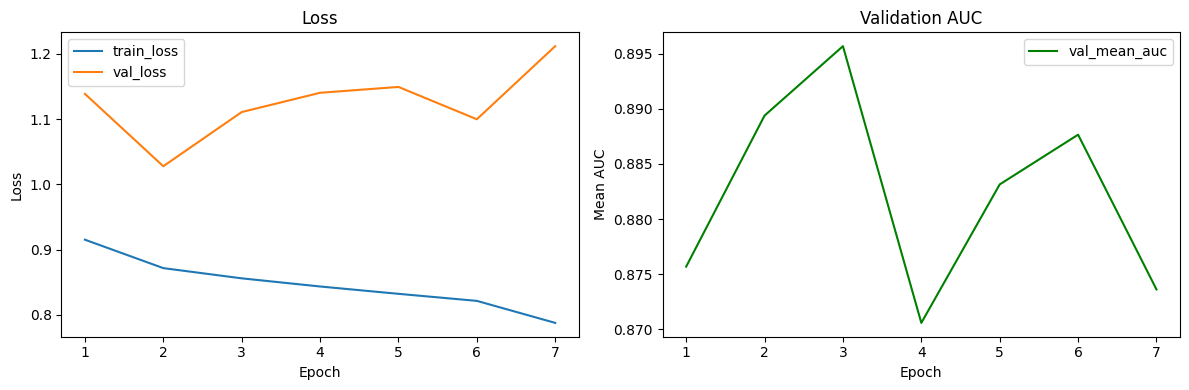

In [12]:
# ---- CELL: Training curves ----
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(hist_df["epoch"], hist_df["val_mean_auc"], label="val_mean_auc", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean AUC"); axes[1].legend(); axes[1].set_title("Validation AUC")
plt.tight_layout()
plt.show()

In [13]:
# ---- CELL: Reload best checkpoint, find per-label optimal thresholds on VALIDATION set ----
best_model = ImageAgent(pretrained=True, dropout=0.3).to(device)
best_model.load_state_dict(torch.load(IMAGE_AGENT_CHECKPOINT, map_location=device, weights_only=True))
best_model.eval()

_, val_probs, val_labels = run_inference(best_model, valid_loader)

# def best_thresholds_youden(all_probs, all_labels):
#     """Pick, per label, the threshold that maximizes (sensitivity + specificity - 1)."""
#     thresholds = {}
#     for i, label_name in enumerate(CHEXPERT_LABELS):
#         y_true, y_scores = all_labels[:, i], all_probs[:, i]
#         if len(np.unique(y_true)) < 2:
#             thresholds[label_name] = 0.5
#             continue
#         fpr, tpr, thr = roc_curve(y_true, y_scores)
#         j_scores = tpr - fpr
#         best_idx = np.argmax(j_scores)
#         thresholds[label_name] = float(thr[best_idx])
#     return thresholds


# optimal_thresholds = best_thresholds_youden(val_probs, val_labels)
# print("Per-label decision thresholds (chosen on validation set, applied to test set):")
# for label_name, t in optimal_thresholds.items():
#     print(f"  {label_name:20s} {t:.3f}")

def best_thresholds_f1(all_probs, all_labels):
    thresholds = {}
    for i, label_name in enumerate(CHEXPERT_LABELS):
        y_true, y_scores = all_labels[:, i], all_probs[:, i]
        if len(np.unique(y_true)) < 2:
            thresholds[label_name] = 0.5
            continue
        candidates = np.linspace(0.05, 0.95, 181)
        best_thr, best_f1 = 0.5, -1
        for thr in candidates:
            preds = (y_scores >= thr).astype(int)
            f1 = f1_score(y_true, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr
        thresholds[label_name] = float(best_thr)
    return thresholds

from sklearn.metrics import f1_score
optimal_thresholds = best_thresholds_f1(val_probs, val_labels)
print(optimal_thresholds)

{'Cardiomegaly': 0.30499999999999994, 'Edema': 0.62, 'Consolidation': 0.5199999999999999, 'Atelectasis': 0.6849999999999999, 'Pleural Effusion': 0.4649999999999999}


In [14]:
# ---- CELL: FINAL evaluation on the held-out TEST set (never used for training or thresholding) ----

_, test_probs, test_labels = run_inference(best_model, test_loader)
test_mean_auc, test_aucs = compute_aucs(test_probs, test_labels)

thresh_array = np.array([optimal_thresholds[l] for l in CHEXPERT_LABELS])
test_preds = (test_probs >= thresh_array).astype(int)

report = {"per_label": {}}
print(f"{'Label':20s} {'AUROC':>7s} {'AUPRC':>7s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'Spec':>7s} {'F1':>6s}")
per_label_acc = []
for i, label_name in enumerate(CHEXPERT_LABELS):
    y_true, y_prob, y_pred = test_labels[:, i], test_probs[:, i], test_preds[:, i]

    auroc = test_aucs.get(label_name, float("nan"))
    auprc = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")

    per_label_acc.append(acc)
    print(f"{label_name:20s} {auroc:7.3f} {auprc:7.3f} {acc*100:6.1f}% {prec*100:6.1f}% "
          f"{rec*100:6.1f}% {specificity*100:6.1f}% {f1:6.3f}")

    report["per_label"][label_name] = {
        "auroc": auroc, "auprc": auprc, "accuracy": acc,
        "precision": prec, "recall": rec, "specificity": specificity, "f1": f1,
        "threshold": optimal_thresholds[label_name],
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

mean_acc = float(np.mean(per_label_acc))
exact_match = float(np.mean(np.all(test_preds == test_labels, axis=1)))
hamming_acc = float(np.mean(test_preds == test_labels))  # per-label-per-sample average

report["overall"] = {
    "mean_auroc": test_mean_auc,
    "mean_per_label_accuracy_pct": mean_acc * 100,
    "exact_match_accuracy_pct": exact_match * 100,
    "hamming_accuracy_pct": hamming_acc * 100,
    "n_test_images": int(len(test_dataset)),
    "n_test_patients": int(test_df["patient_id"].nunique()),
}

print(f"\nOverall mean AUROC (test):            {test_mean_auc:.3f}")
print(f"Mean per-label accuracy (test):       {mean_acc*100:.2f}%")
print(f"Hamming accuracy (per-label, test):   {hamming_acc*100:.2f}%")
print(f"Exact-match accuracy (all 5, test):    {exact_match*100:.2f}%")

with open(METRICS_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)
print(f"\nFull metrics report saved to {METRICS_REPORT_PATH}")

Label                  AUROC   AUPRC     Acc    Prec  Recall    Spec     F1
Cardiomegaly           0.851   0.503   70.2%   27.5%   85.0%   68.1%  0.416
Edema                  0.845   0.708   76.6%   61.0%   74.6%   77.5%  0.671
Consolidation          0.726   0.157   70.9%   12.7%   59.0%   71.8%  0.210
Atelectasis            0.706   0.490   64.7%   45.1%   63.6%   65.2%  0.528
Pleural Effusion       0.863   0.828   78.3%   73.9%   79.6%   77.3%  0.766

Overall mean AUROC (test):            0.798
Mean per-label accuracy (test):       72.14%
Hamming accuracy (per-label, test):   72.14%
Exact-match accuracy (all 5, test):    23.69%

Full metrics report saved to /kaggle/working/checkpoints/test_metrics_report.json


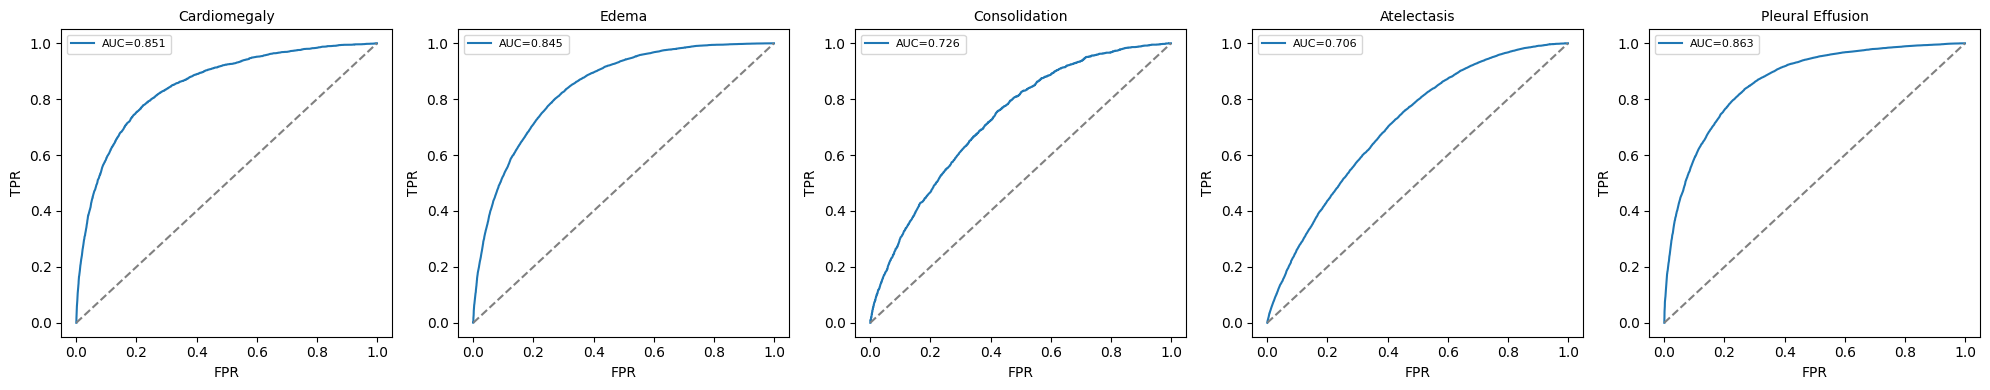

In [15]:
# ---- CELL: ROC curves per label (test set) ----
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for i, label_name in enumerate(CHEXPERT_LABELS):
    y_true, y_prob = test_labels[:, i], test_probs[:, i]
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[i].plot(fpr, tpr, label=f"AUC={test_aucs.get(label_name, float('nan')):.3f}")
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[i].set_title(label_name, fontsize=10)
    axes[i].set_xlabel("FPR"); axes[i].set_ylabel("TPR"); axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

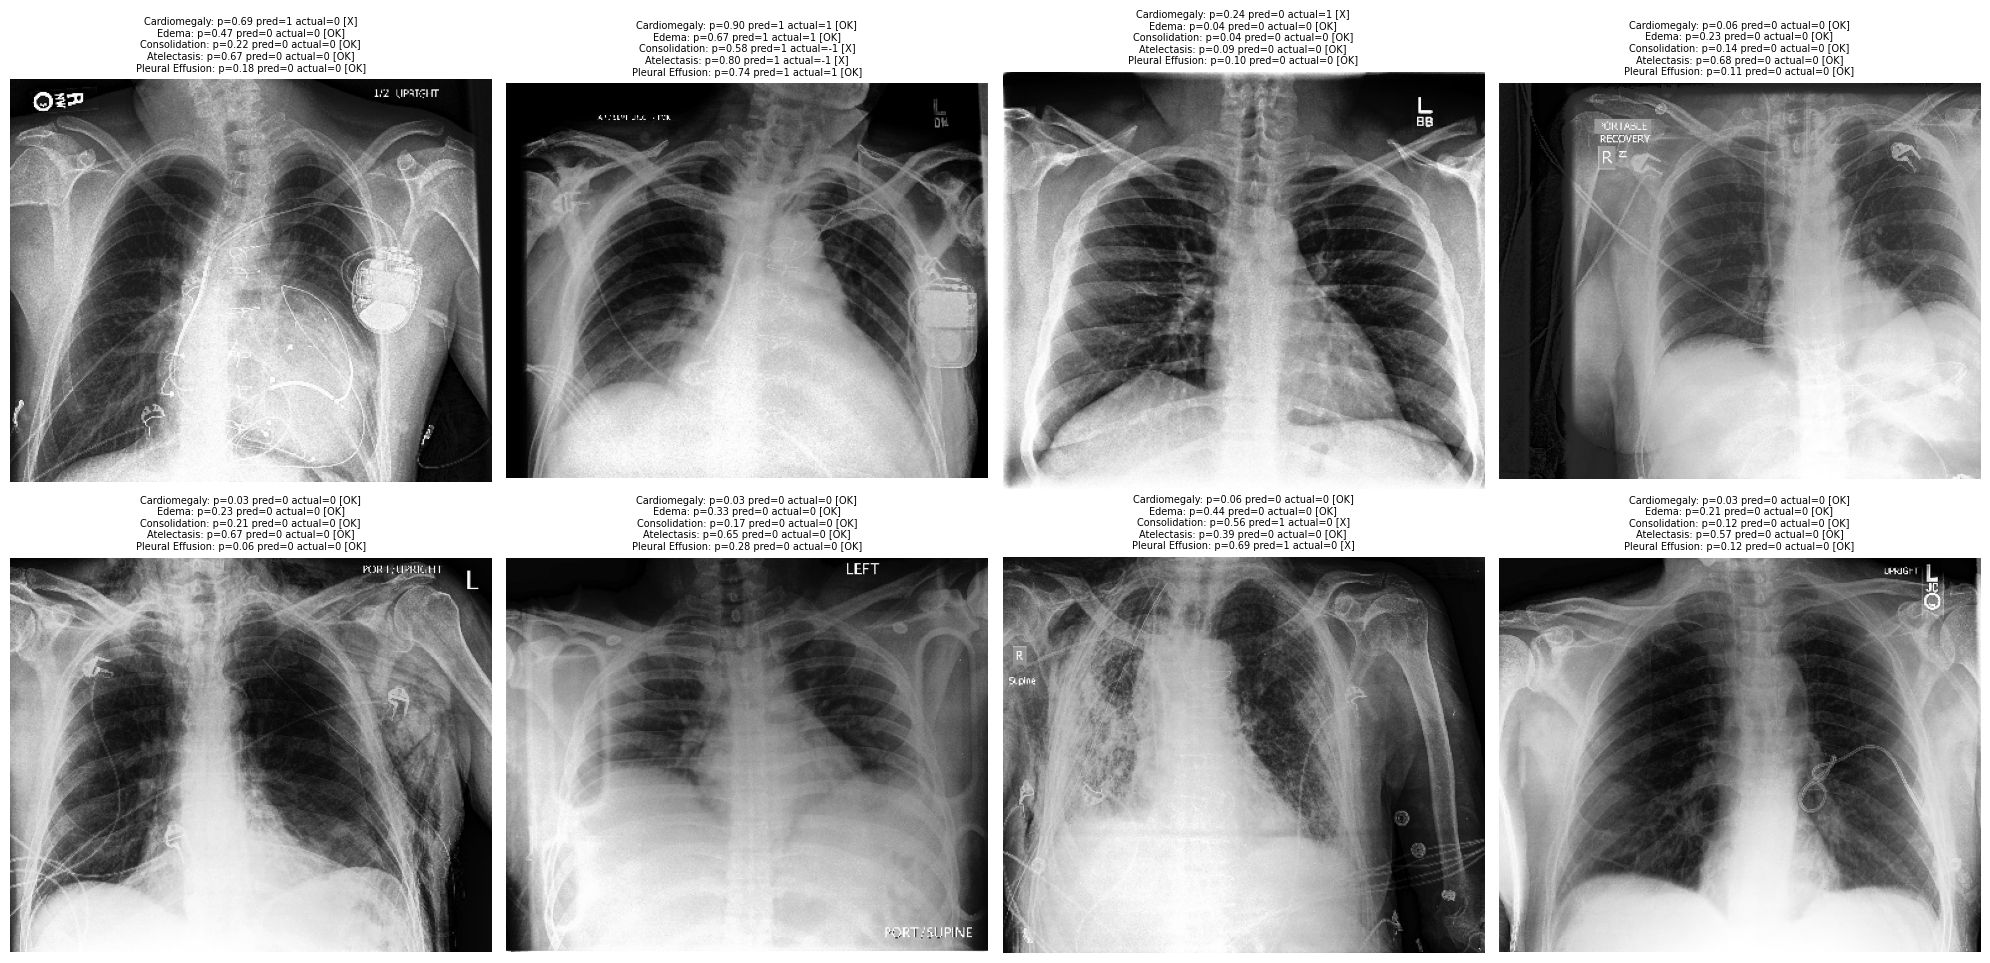

In [16]:
# ---- CELL: Honest qualitative sample from the TEST set, using optimized thresholds ----
test_transform = build_transforms(train=False)

def predict_one(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = test_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = best_model(tensor)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    preds = {label: (float(p), int(p >= optimal_thresholds[label])) for label, p in zip(CHEXPERT_LABELS, probs)}
    return preds, image

n_samples = 8
sample_rows = test_dataset.df.sample(n=n_samples, random_state=1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img_path = _resolve_image_path(row["Path"], DATASET_ROOT)
    preds, image = predict_one(img_path)

    ax.imshow(image, cmap="gray")
    ax.axis("off")

    lines = []
    for k, (prob, pred_bin) in preds.items():
        actual = int(row[k])
        mark = "OK" if pred_bin == actual else "X"
        lines.append(f"{k}: p={prob:.2f} pred={pred_bin} actual={actual} [{mark}]")
    ax.set_title("\n".join(lines), fontsize=7)

plt.tight_layout()
plt.show()

In [17]:
print("Uncertain (-1) counts in train_df:")
print((train_df[CHEXPERT_LABELS] == -1).sum())

Uncertain (-1) counts in train_df:
Cardiomegaly         6876
Edema               11086
Consolidation       23721
Atelectasis         28808
Pleural Effusion     9976
dtype: int64
